# Fermi-Dirac Electronic Occupations

This notebook computes finite-temperature electronic occupations for a tight-binding chain. The physics target is the Fermi-Dirac matrix function

$$f_\eta(H-\mu I)=
\frac{1}{1+e^{\eta(H-\mu I)}}.$$

A bounded polynomial approximation acts on the scaled Hamiltonian and is compared with the exact spectral density matrix.

## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a tight-binding electronic-occupation problem.

**QSVT implementation.** It fits a Fermi-Dirac occupation function as a polynomial on the rescaled spectrum. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Exact spectral occupations and site densities validate the approximation. The QSVT primitive is polynomial application of smooth occupation functions to large electronic Hamiltonians represented by block encodings.


## Variable definitions

- `n_sites`: number of tight-binding sites.
- `onsite`: periodic onsite-potential pattern.
- `H`: tight-binding Hamiltonian.
- `scaled`: rescaling metadata for `H`.
- `evals`, `scaled_evals`: eigenvalues before and after rescaling.
- `chemical_potential`: Fermi level.
- `beta`: inverse-temperature parameter.
- `fermi_energy`: physical-energy Fermi-Dirac function.
- `fermi_scaled`: scaled-variable version of the Fermi-Dirac function.
- `cheb_coeffs`: Chebyshev coefficients from fitting.
- `coeffs`: monomial polynomial coefficients.
- `rho_exact`, `rho_poly`: exact and polynomial one-particle density matrices.
- `occupation_error`: relative density-matrix error.
- `particle_number_exact`, `particle_number_poly`: exact and polynomial particle numbers.
- `fermi_exact_values`, `fermi_poly_values`: occupations on exact eigenvalues.
- `occupation_residual`: pointwise polynomial occupation error on exact eigenvalues.
- `site_density_exact`, `site_density_poly`: site occupations from the density matrices.
- `fig`, `axes`, and similar names are plotting helpers.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.approximation import chebyshev_fit_function
from qsvt.hamiltonians import tight_binding_chain
from qsvt.polynomials import chebyshev_to_monomial, eval_polynomial
from qsvt.rescaling import rescale_hermitian_to_unit_interval
from qsvt.spectral import (
    apply_function_to_hermitian,
    apply_polynomial_to_hermitian,
    eigh_hermitian,
)

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_sites = 18
onsite = 0.25 * np.cos(2 * np.pi * np.arange(n_sites) / n_sites)
H = tight_binding_chain(n_sites, hopping=1.0, onsite=onsite, periodic=True)
scaled = rescale_hermitian_to_unit_interval(H)
evals, _ = eigh_hermitian(H)
scaled_evals = np.linalg.eigvalsh(scaled.matrix)

chemical_potential = 0.15
beta = 6.0


def fermi_energy(energy):
    return 1.0 / (1.0 + np.exp(beta * (energy - chemical_potential)))


def fermi_scaled(x):
    energy = scaled.original_from_scaled_value(x)
    return fermi_energy(energy)


cheb_coeffs = chebyshev_fit_function(fermi_scaled, degree=35, num_points=2001)
coeffs = chebyshev_to_monomial(cheb_coeffs)

rho_exact = apply_function_to_hermitian(H, fermi_energy)
rho_poly = apply_polynomial_to_hermitian(scaled.matrix, coeffs)
occupation_error = np.linalg.norm(rho_poly - rho_exact) / np.linalg.norm(rho_exact)
particle_number_exact = np.trace(rho_exact).real
particle_number_poly = np.trace(rho_poly).real
print(f"Occupation Error: {occupation_error}")
print(f"Exact Particle Number [electrons]: {particle_number_exact}")
print(f"Polynomial Particle Number [electrons]: {particle_number_poly}")

Occupation Error: 7.804084211610466e-05
Exact Particle Number [electrons]: 9.385723227081577
Polynomial Particle Number [electrons]: 9.385329756322626


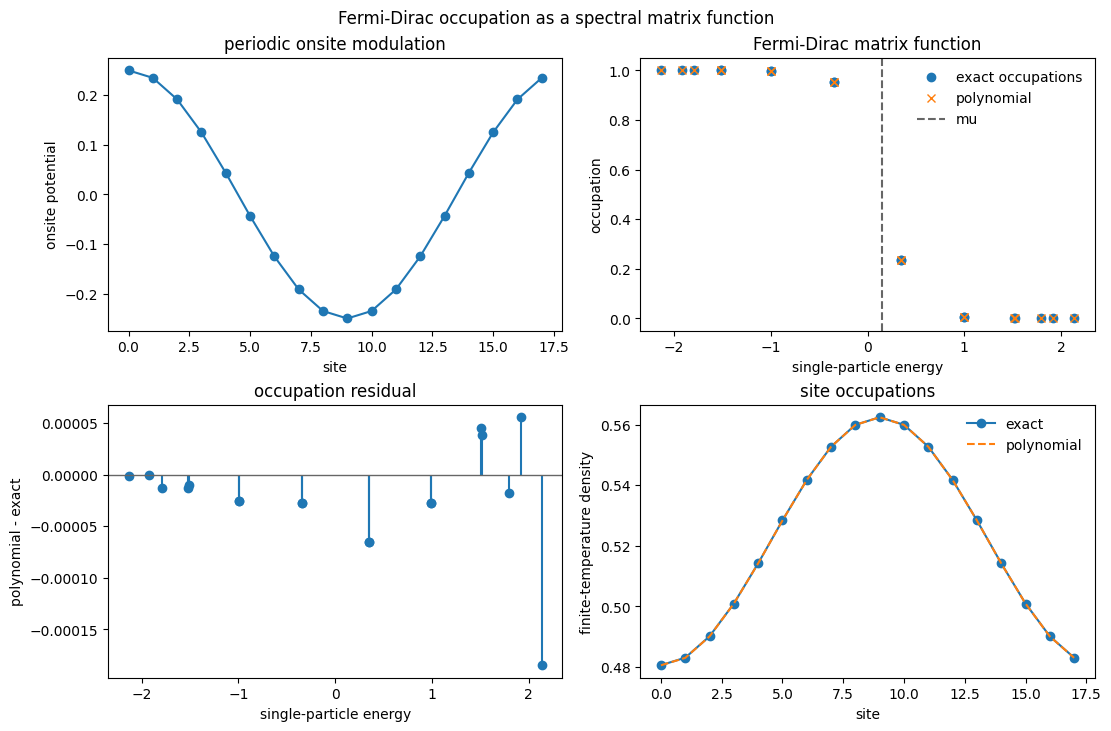

In [3]:
fermi_exact_values = fermi_energy(evals)
fermi_poly_values = eval_polynomial(coeffs, scaled_evals)
site_density_exact = np.real(np.diag(rho_exact))
site_density_poly = np.real(np.diag(rho_poly))
occupation_residual = fermi_poly_values - fermi_exact_values
site = np.arange(n_sites)

fig, axes = plt.subplots(2, 2, figsize=(11, 7.2), constrained_layout=True)

axes[0, 0].plot(site, onsite, "o-")
axes[0, 0].set_xlabel("site")
axes[0, 0].set_ylabel("onsite potential")
axes[0, 0].set_title("periodic onsite modulation")

axes[0, 1].plot(evals, fermi_exact_values, "o", label="exact occupations")
axes[0, 1].plot(evals, fermi_poly_values, "x", label="polynomial")
axes[0, 1].axvline(chemical_potential, color="0.4", linestyle="--", label="mu")
axes[0, 1].set_xlabel("single-particle energy")
axes[0, 1].set_ylabel("occupation")
axes[0, 1].set_title("Fermi-Dirac matrix function")
axes[0, 1].legend(frameon=False)

axes[1, 0].stem(evals, occupation_residual, basefmt=" ")
axes[1, 0].axhline(0.0, color="0.4", linewidth=1.0)
axes[1, 0].set_xlabel("single-particle energy")
axes[1, 0].set_ylabel("polynomial - exact")
axes[1, 0].set_title("occupation residual")

axes[1, 1].plot(site, site_density_exact, "o-", label="exact")
axes[1, 1].plot(site, site_density_poly, "--", label="polynomial")
axes[1, 1].set_xlabel("site")
axes[1, 1].set_ylabel("finite-temperature density")
axes[1, 1].set_title("site occupations")
axes[1, 1].legend(frameon=False)

fig.suptitle("Fermi-Dirac occupation as a spectral matrix function")
plt.show()

In [4]:
assert occupation_error < 0.02
assert abs(particle_number_poly - particle_number_exact) < 0.05
assert np.all(fermi_poly_values > -0.02)
assert np.all(fermi_poly_values < 1.02)

print(f"relative_density_matrix_error: {occupation_error:.4f}")
print(f"exact_particle_number [electrons]: {particle_number_exact:.3f}")
print(f"polynomial_particle_number [electrons]: {particle_number_poly:.3f}")
print("validation: passed")

relative_density_matrix_error: 0.0001
exact_particle_number [electrons]: 9.386
polynomial_particle_number [electrons]: 9.385
validation: passed
